In [1]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Model Training

In [2]:
log_folder = '/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/slurms/'
#file_names = ['5033695_1','4854100_2','4854310_4']
file_names = ['5436256_1', '5436256_2','5436256_4', '5436256_5']

In [3]:
sub_list = ['sub-01', 'sub-02', 'sub-04', 'sub-05']
logs = {}
for i, sub in enumerate(sub_list):
    print(file_names[i])
    print(sub)
    file_path = os.path.join(log_folder, f'{file_names[i]}.err')
    with open(file_path, 'r') as f:
        logs[sub] = f.read()

5436256_1
sub-01
5436256_2
sub-02
5436256_4
sub-04
5436256_5
sub-05


In [10]:
# PixCorr (pixel correlation), SSIM (structural similarity in-
# dex metric; Zhou Wang et al., 2004), EfficientNet-B1 (“Eff”;
# Tan & Le, 2020) and SwAV-ResNet50 (“SwAV”; Caron
# et al., 2021) compute the average correlation distance be-
# tween the ground truth and reconstructed image. AlexNet
# (layers 2 and 5) (Krizhevsky et al., 2012), Inception-v3 (last
# pooling layer) (Szegedy et al., 2016), and CLIP (last layer
# of ViT-L/14) (Radford et al., 2021) use two-way compar-
# isons based on extracted features from the specified layer
# (chance=50%). For each test image, we compute the Pear-
# son’s correlation of each ground truth image with each re-
# construction in the test set; two-way accuracy refers to the
# number of times the correct ground-truth reconstruction pair
# is more correlated than a mismatched pair, averaged over all
# possible pairwise comparisons and then over all test images
# to produce a single score.


#test/loss
#test/loss_clip_total
#test/loss_prior
#test/num_steps
#test/recon_cossim
#test/recon_mse
#test/test_bwd_pct_correct
#test/test_fwd_pct_correct
#train/bwd_pct_correct=0.0362
#train/fwd_pct_correct=0.0458, 

#train/loss
#train/loss_clip_total
#train/loss_prior

#train/lr
#train/num_steps
#train/recon_cossim
#train/recon_mse=0.346


# test/loss=13.4, 
# test/loss_clip_total=2.04, 
# test/loss_prior=0.379, 
# test/num_steps=140, 
# test/test_bwd_pct_correct overall=0.333, 
# test/test_bwd_pct_correct snap=0.361, 
# test/test_bwd_pct_correct study=0.194, 
# test/test_bwd_pct_correct test=0.306, 
# test/test_fwd_pct_correct overall=0.389, 
# test/test_fwd_pct_correct snap=0.472, 
# test/test_fwd_pct_correct study=0.25, 
# test/test_fwd_pct_correct test=0.194, 
# train/bwd_pct_correct=1, 
# train/fwd_pct_correct=1, 
# train/loss=5.92, 
# train/loss_clip_total=0.000703, 
# train/loss_prior=0.197, 
# train/lr=3.38e-6, train/num_steps=8540]

metrics = ['train/loss', 'train/fwd_pct_correct','train/bwd_pct_correct',
           'test/loss_clip_total', 'test/test_fwd_pct_correct overall','test/test_bwd_pct_correct overall',
           'test/test_bwd_pct_correct study', 'test/test_bwd_pct_correct test', 'test/test_bwd_pct_correct snap',
           'test/test_fwd_pct_correct study', 'test/test_fwd_pct_correct test', 'test/test_fwd_pct_correct snap']

In [11]:
def extract_num(keyword, string):
    # Pattern explanation:
    # (?<=" + keyword + "=) is a positive lookbehind assertion, matching the position after the keyword and "=".
    # \\d+ matches one or more digits.
    pattern = r"(?<=" + keyword + r"=)\d+\.?\d*"
    
    # re.findall returns all non-overlapping matches of the pattern as a list of strings.
    numbers_str_list = re.findall(pattern, string)

    # Convert the list of string numbers to a list of integers
    numbers_list = [float(num) for num in numbers_str_list]

    print(f"{keyword} found {len(numbers_list)}.")

    return numbers_list

train/loss found 301.
train/fwd_pct_correct found 301.
train/bwd_pct_correct found 301.
test/loss_clip_total found 301.
test/test_fwd_pct_correct overall found 301.
test/test_bwd_pct_correct overall found 301.
test/test_bwd_pct_correct study found 301.
test/test_bwd_pct_correct test found 301.
test/test_bwd_pct_correct snap found 301.
test/test_fwd_pct_correct study found 301.
test/test_fwd_pct_correct test found 301.
test/test_fwd_pct_correct snap found 301.


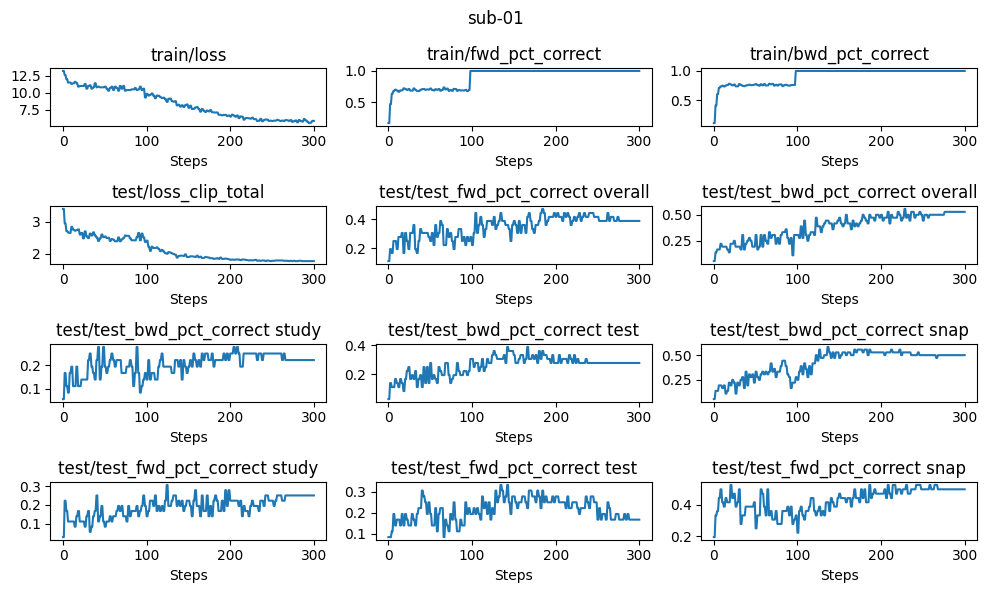

train/loss found 301.
train/fwd_pct_correct found 301.
train/bwd_pct_correct found 301.
test/loss_clip_total found 301.
test/test_fwd_pct_correct overall found 301.
test/test_bwd_pct_correct overall found 301.
test/test_bwd_pct_correct study found 301.
test/test_bwd_pct_correct test found 301.
test/test_bwd_pct_correct snap found 301.
test/test_fwd_pct_correct study found 301.
test/test_fwd_pct_correct test found 301.
test/test_fwd_pct_correct snap found 301.


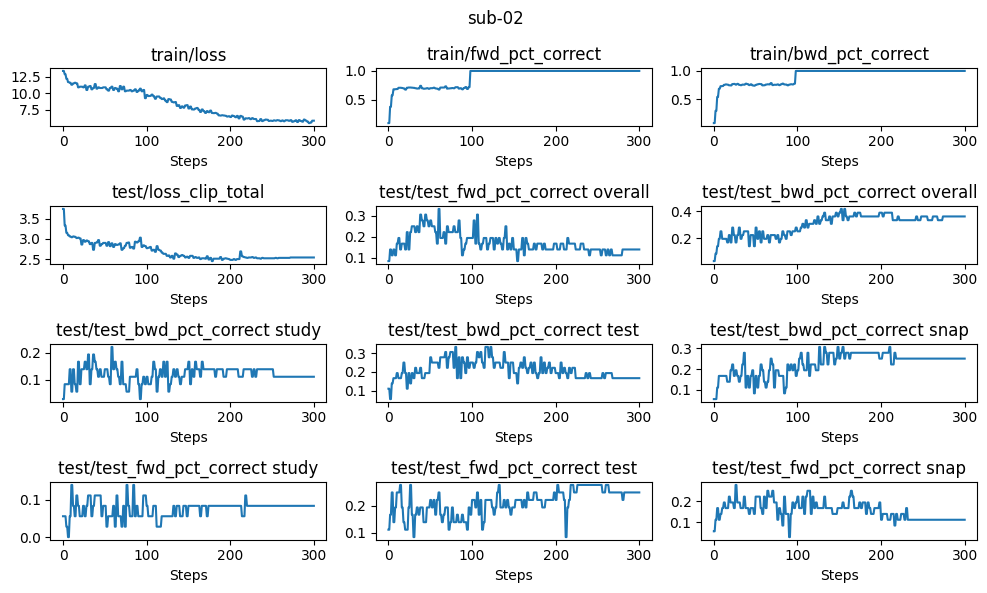

train/loss found 301.
train/fwd_pct_correct found 301.
train/bwd_pct_correct found 301.
test/loss_clip_total found 301.
test/test_fwd_pct_correct overall found 301.
test/test_bwd_pct_correct overall found 301.
test/test_bwd_pct_correct study found 301.
test/test_bwd_pct_correct test found 301.
test/test_bwd_pct_correct snap found 301.
test/test_fwd_pct_correct study found 301.
test/test_fwd_pct_correct test found 301.
test/test_fwd_pct_correct snap found 301.


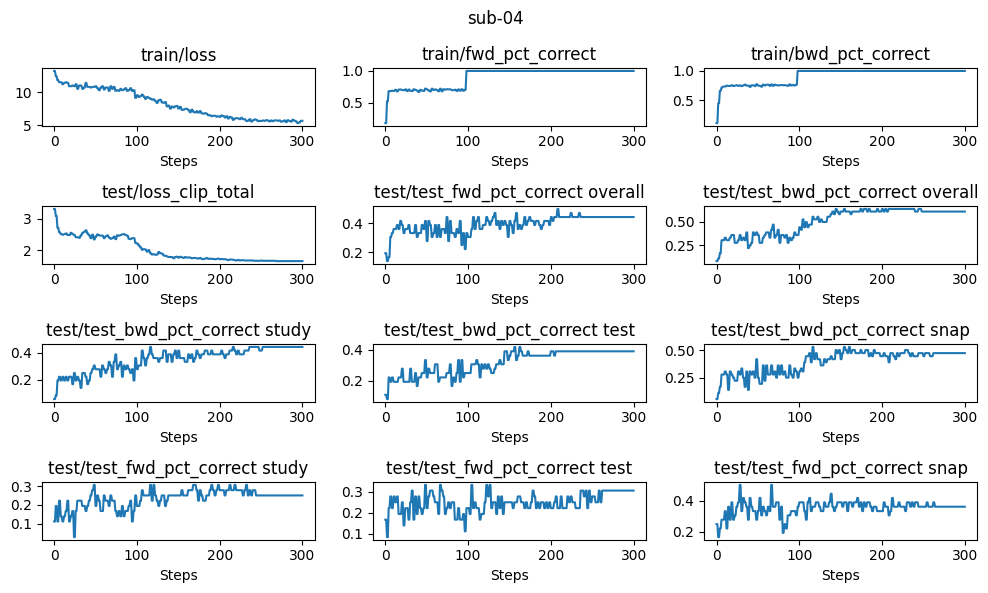

train/loss found 301.
train/fwd_pct_correct found 301.
train/bwd_pct_correct found 301.
test/loss_clip_total found 301.
test/test_fwd_pct_correct overall found 301.
test/test_bwd_pct_correct overall found 301.
test/test_bwd_pct_correct study found 301.
test/test_bwd_pct_correct test found 301.
test/test_bwd_pct_correct snap found 301.
test/test_fwd_pct_correct study found 301.
test/test_fwd_pct_correct test found 301.
test/test_fwd_pct_correct snap found 301.


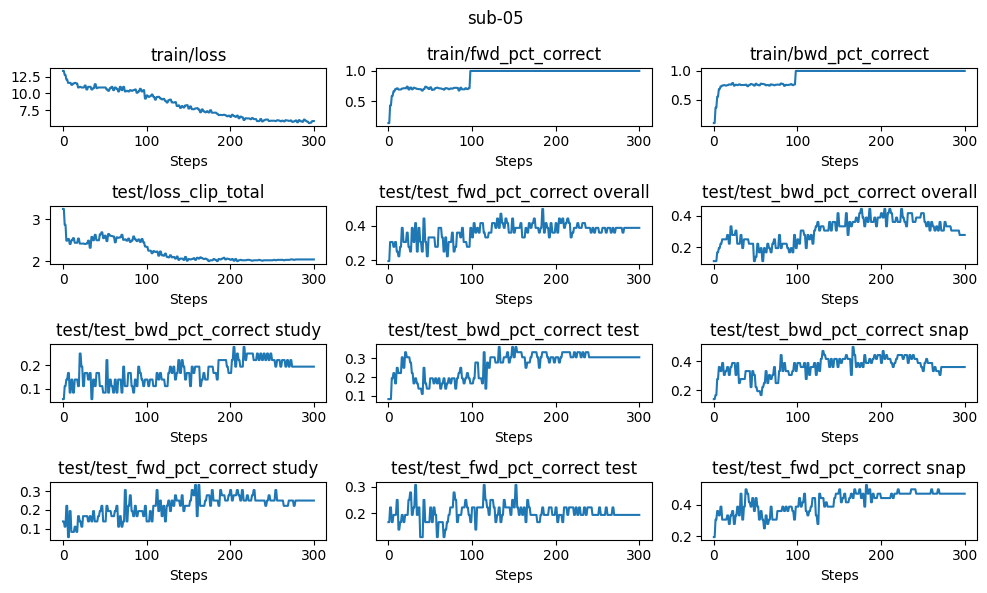

In [15]:
all_sub_dict = {}

for sub in sub_list:
    all_sub_dict[sub] = {}
    for i, metric in enumerate(metrics):
        all_sub_dict[sub][metric] = extract_num(metric, logs[sub])
    
    
    num_dict = all_sub_dict[sub]
    import math

    # Determine the number of subplots needed
    num_plots = len(num_dict)
    # Calculate the grid dimensions (e.g., 2 rows, 2 columns for 4 plots)
    num_cols = 3

    num_rows = math.ceil(num_plots / num_cols)

    # 2. Create a figure and a set of subplots
    # The 'axs' variable will be a 1D or 2D array of Axes objects
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(10, 6), tight_layout=True)

    # 3. Flatten the axes array for easy iteration if it's 2D
    if num_rows > 1 and num_cols > 1:
        axs = axs.flatten()

    # 4. Iterate over the dictionary and the axes to plot the data
    for i, (key, value) in enumerate(num_dict.items()):
        ax = axs[i]
        ax.plot(value)
        ax.set_title(key) # Set the title for each subplot
        ax.set_xlabel('Steps')

    # 5. Remove any unused subplots if the grid is larger than needed
    if num_plots < len(axs):
        for j in range(num_plots, len(axs)):
            fig.delaxes(axs[j])

    # 6. Display the plot
    fig.suptitle(sub)
    plt.show()

In [10]:
# df = pd.DataFrame(columns=metrics+['sub'])

# for sub in sub_list:
#     sub_df = pd.DataFrame(num_dict[sub])
#     sub_df['sub'] = sub
    
#     df = pd.concat([df, sub_df], ignore_index=True)

/tmp/ipykernel_3388128/897763415.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, sub_df], ignore_index=True)


In [8]:
# df.to_csv("bixby_data/loss_acc.csv")

## Model Eval

In [2]:
import pickle
from tqdm import tqdm
from collections import defaultdict
from scipy.stats import zscore
import utils
import bixby_utils

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
subs = ['sub-01', 'sub-02', 'sub-04', 'sub-05']

utils.seed_everything(315)

dic = {}

test_images = [f'A_{i}' for i in range(1,19)] + [f'B_{i}' for i in range(1,19)]

data_folder = '/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/'

sessions = ['study', 'test', 'snap']

folder_path = os.path.join(data_folder, 'afni')

for sub in subs:

    with open(f'{folder_path}/{sub}_roi_vox_all_sessions.pkl', 'rb') as file:
        dic[sub] = pickle.load(file)

    union_mask = dic[sub]['union_mask']
    print('NSD mask size:', union_mask.shape)
    print('union mask size:', sum(union_mask))
    for ses in sessions:
        dic[sub][ses]['roi'] = dic[sub][ses]['roi'][:, union_mask]
        # z-score each session
        dic[sub][ses]['roi'] = np.nan_to_num(zscore(dic[sub][ses]['roi'], axis=0))
        s = dic[sub][ses]['roi'].shape
        print(f'{ses}: {s}')

NSD mask size: (16946,)
union mask size: 6886
study: (216, 6886)
test: (216, 6886)
snap: (432, 6886)
NSD mask size: (17175,)
union mask size: 4144
study: (216, 4144)
test: (216, 4144)
snap: (432, 4144)
NSD mask size: (20397,)
union mask size: 6018
study: (216, 6018)
test: (216, 6018)
snap: (432, 6018)
NSD mask size: (19907,)
union mask size: 8441
study: (216, 8441)
test: (216, 8441)
snap: (432, 8441)


In [5]:
for key in dic:
    for ses in sessions:
        print(key, ses)
        print(dic[key][ses]['trial'][0])
        print(dic[key][ses]['roi'].shape)

sub-01 study
scene_A_10_study
(216, 6886)
sub-01 test
scene_A_10_test
(216, 6886)
sub-01 snap
scene_A_10_1
(432, 6886)
sub-02 study
scene_A_10_study
(216, 4144)
sub-02 test
scene_A_10_test
(216, 4144)
sub-02 snap
scene_A_10_1
(432, 4144)
sub-04 study
scene_A_10_study
(216, 6018)
sub-04 test
scene_A_10_test
(216, 6018)
sub-04 snap
scene_A_10_1
(432, 6018)
sub-05 study
scene_A_10_study
(216, 8441)
sub-05 test
scene_A_10_test
(216, 8441)
sub-05 snap
scene_A_10_1
(432, 8441)


In [6]:
import torch
from torchvision import transforms
import imageio.v2 as imageio

resize_transform = transforms.Resize((224, 224))

test_img_tensor = None
# img_path = f'/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/afni/loaded_test_imgs.pkl'

# if os.path.exists(img_path):
#     with open(img_path, 'rb') as file:
#         test_img_tensor = pickle.load(file)
#         print('Loading image saved at: ', file)
# else:
for img in test_images:

    root_dir = os.path.join(data_folder, 'stimuli', 'scenes')
    img_list = img.split('_')[0]
    img_id = int(img.split('_')[1])

    image_file = f'{root_dir}/list{img_list}/{img_id:02d}.png'

    if image_file and not os.path.exists(image_file):
        print('Cannot find the image at this path',image_file)
        break

    im = imageio.imread(image_file)
    im = torch.Tensor(im / 255).permute(2,0,1)
    im = resize_transform(im.unsqueeze(0))

    if test_img_tensor is None:
        test_img_tensor = im
    else:
        test_img_tensor = torch.vstack((test_img_tensor, im))


    # print(folder_path)
    # with open(img_path, 'wb') as file:
    #     pickle.dump(test_img_tensor, file)
    #     print('image saved at: ', file)
print("testing images", test_img_tensor.shape)

/home/wg7536/.conda/envs/rt_mindEye2/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


testing images torch.Size([36, 3, 224, 224])


In [7]:
# Loading data averaged across run
tasks = ['study', 'test', 'snap']

test_data = {}

for sub in subs:
    
    test_data[sub] = {}
    
    for task in tasks:

        sub_dict = dic[sub][task]

        repeat_idx, per_run_repeat_idx = bixby_utils.locate_repeat_index_per_run(sub_dict, test_images)

        test_data[sub][task] = bixby_utils.average_repeats_across_run(sub_dict['roi'], repeat_idx, test_images) # averaging all repeats across run in the sequence of test_images

In [8]:
# Loading data per run

per_run_data = {}

for sub in subs:
    
    per_run_data[sub] = {}
    
    for task in tasks:

        sub_dict = dic[sub][task]

        repeat_idx, per_run_repeat_idx = bixby_utils.locate_repeat_index_per_run(sub_dict, test_images)

        per_run_data[sub][task] = bixby_utils.average_repeats_for_each_run(sub_dict['roi'], per_run_repeat_idx, test_images)
            
    per_run_data[sub]['all_task'] = {}
    
    for run in per_run_data[sub][task].keys():

        per_run_data[sub]['all_task'][run] = np.mean([per_run_data[sub][tasks[0]][run], per_run_data[sub][tasks[1]][run], per_run_data[sub][tasks[2]][run]], axis=0)

In [9]:
sub = 'sub-02'

In [10]:
output_dict = {}
output_dict[sub] = {}

### Loading pre-trained subject model

In [11]:
outdir_folder = '/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/'
folder_names = {'sub-01':'output_sub-01_sub-01_3-session_task-mindeye_1bixby-main-multisession_afni_avgrepeats_unionmask_150epochs_1772834088.0768142',
                'sub-02':'output_sub-02_sub-02_3-session_task-mindeye_2bixby-main-multisession_afni_avgrepeats_unionmask_150epochs_1772834088.0764399', 
                'sub-04':'output_sub-04_sub-04_3-session_task-mindeye_4bixby-main-multisession_afni_avgrepeats_unionmask_150epochs_1772834730.512949',
                'sub-05':'output_sub-05_sub-05_3-session_task-mindeye_5bixby-main-multisession_afni_avgrepeats_unionmask_150epochs_1772834813.2468472'}

outdir = os.path.join(outdir_folder, folder_names[sub])

In [12]:
outdir

'/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/output_sub-02_sub-02_3-session_task-mindeye_2bixby-main-multisession_afni_avgrepeats_unionmask_150epochs_1772834088.0764399'

In [13]:
def load_ckpt(tag,load_lr=True,load_optimizer=True,load_epoch=True,strict=True,outdir=outdir,multisubj_loading=False): 
    print(f"\n---loading {outdir}/{tag}.pth ckpt---\n")
    checkpoint = torch.load(outdir+'/last.pth', map_location='cpu')
    state_dict = checkpoint['model_state_dict']
    if multisubj_loading: # remove incompatible ridge layer that will otherwise error
        state_dict.pop('ridge.linears.0.weight',None)
    model.load_state_dict(state_dict, strict=strict)
    if load_epoch:
        globals()["epoch"] = checkpoint['epoch']
        print("Epoch",epoch)
    if load_optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if load_lr:
        lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
    del checkpoint

In [14]:
import torch
import torch.nn as nn
### Multi-GPU config ###
from accelerate import Accelerator, DeepSpeedPlugin

local_rank = os.getenv('RANK')
if local_rank is None: 
    local_rank = 0
else:
    local_rank = int(local_rank)
print("LOCAL RANK ", local_rank)  

data_type = torch.float32 # change depending on your mixed_precision

accelerator = Accelerator(split_batches=False)

device = accelerator.device

LOCAL RANK  0


In [15]:
print("PID of this process =",os.getpid())
device = accelerator.device
print("device:",device)
world_size = accelerator.state.num_processes
distributed = not accelerator.state.distributed_type == 'NO'
num_devices = torch.cuda.device_count()
if num_devices==0 or not distributed: num_devices = 1
num_workers = num_devices
print(accelerator.state)

# set data_type to match your mixed precision (automatically set based on deepspeed config)
if accelerator.mixed_precision == "bf16":
    data_type = torch.bfloat16
elif accelerator.mixed_precision == "fp16":
    data_type = torch.float16
else:
    data_type = torch.float32

print("distributed =",distributed, "num_devices =", num_devices, "local rank =", local_rank, "world size =", world_size, "data_type =", data_type)
print = accelerator.print # only print if local_rank=0

PID of this process = 2695392
device: cuda
Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

distributed = False num_devices = 1 local rank = 0 world size = 1 data_type = torch.float32


In [16]:
from models import PriorNetwork, BrainDiffusionPrior
import utils

## USING OpenCLIP ViT-bigG ###
sys.path.append('generative_models/')
import sgm
from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder
# from generative_models.sgm.models.diffusion import DiffusionEngine
# from omegaconf import OmegaConf

try:
    print(clip_img_embedder)
except:
    clip_img_embedder = FrozenOpenCLIPImageEmbedder(
        arch="ViT-bigG-14",
        version="laion2b_s39b_b160k",
        output_tokens=True,
        only_tokens=True,
    )
    clip_img_embedder.to(device)
clip_img_embedder.model.visual.set_grad_checkpointing(True)

clip_seq_dim = 256
clip_emb_dim = 1664

In [17]:
num_voxels_list = [dic[sub]['study']['roi'].shape[-1]]
n_blocks=4
hidden_dim=1024
use_prior=True
clip_scale=1.

model = utils.prepare_model_and_training(
    num_voxels_list=num_voxels_list,
    n_blocks=n_blocks,
    hidden_dim=hidden_dim,
    clip_emb_dim=clip_emb_dim,
    clip_seq_dim=clip_seq_dim,
    use_prior=use_prior,
    clip_scale=clip_scale
)

MindEyeModule()
param counts:
4,244,480 total
4,244,480 trainable
param counts:
4,244,480 total
4,244,480 trainable
param counts:
453,360,280 total
453,360,280 trainable
param counts:
457,604,760 total
457,604,760 trainable
param counts:
259,865,216 total
259,865,200 trainable
param counts:
717,469,976 total
717,469,960 trainable


In [18]:
epoch = 0
losses, test_losses, lrs = [], [], []
best_test_loss = 1e9
torch.cuda.empty_cache()
# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True

In [19]:
load_ckpt("last",
          outdir=outdir,load_lr=False,load_optimizer=False,load_epoch=False,
          strict=False,multisubj_loading=False)
model.to(device)


---loading /scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/output_sub-02_sub-02_3-session_task-mindeye_2bixby-main-multisession_afni_avgrepeats_unionmask_150epochs_1772834088.0764399/last.pth ckpt---



MindEyeModule(
  (ridge): RidgeRegression(
    (linears): ModuleList(
      (0): Linear(in_features=4144, out_features=1024, bias=True)
    )
  )
  (backbone): BrainNetwork(
    (mixer_blocks1): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1024, out_features=1024, bias=True)
        )
      )
    )
    (mixer_blocks2): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1, out_features=1, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1, out_features=1, bias=True)
        )
      )
    )
    (backbone_linear): Linear(i

In [20]:
test_images

['A_1',
 'A_2',
 'A_3',
 'A_4',
 'A_5',
 'A_6',
 'A_7',
 'A_8',
 'A_9',
 'A_10',
 'A_11',
 'A_12',
 'A_13',
 'A_14',
 'A_15',
 'A_16',
 'A_17',
 'A_18',
 'B_1',
 'B_2',
 'B_3',
 'B_4',
 'B_5',
 'B_6',
 'B_7',
 'B_8',
 'B_9',
 'B_10',
 'B_11',
 'B_12',
 'B_13',
 'B_14',
 'B_15',
 'B_16',
 'B_17',
 'B_18']

In [21]:
for img in test_images:
    
    pairs = []
    
    for i in range(1,19):
        
        a = f'A_{i}'
        b = f'B_{i}'

        pairs.append([test_images.index(a), test_images.index(b)])
        
for i, pair in enumerate(pairs):
    print(pair)

[0, 18]
[1, 19]
[2, 20]
[3, 21]
[4, 22]
[5, 23]
[6, 24]
[7, 25]
[8, 26]
[9, 27]
[10, 28]
[11, 29]
[12, 30]
[13, 31]
[14, 32]
[15, 33]
[16, 34]
[17, 35]


In [22]:
def evaluate_MST(vox, images, pairs):

    score = 0
    total = 0

    torch.cuda.empty_cache()
    model.eval()
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type):
        for pair in pairs:
            voxel = vox[pair[0]].to(device)[None]
            voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

            imageA = images[pair[0]].to(device)[None]
            imageB = images[pair[1]].to(device)[None]

            clip_targetA = clip_img_embedder(imageA.float())
            clip_targetB = clip_img_embedder(imageB.float())

            voxel_ridge = model.ridge(voxel,0)
            backbone, clip_voxels, _ = model.backbone(voxel_ridge)

            clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
            clip_targetA_norm = nn.functional.normalize(clip_targetA.flatten(1), dim=-1)
            clip_targetB_norm = nn.functional.normalize(clip_targetB.flatten(1), dim=-1)

            voxel1 = clip_voxels_norm

            if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm):
                score += 1
            total += 1

            voxel = vox[pair[1]].to(device)[None]
            voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

            voxel_ridge = model.ridge(voxel,0)
            backbone, clip_voxels, _ = model.backbone(voxel_ridge)
            clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)

            if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm):
                score += 1
            total += 1

            #print('voxels similarity:', utils.pairwise_cosine_similarity(voxel1, clip_voxels_norm))
            #print('image/voxel similarity:', utils.pairwise_cosine_similarity(voxel1, clip_targetA_norm))
            #print('comp_image/voxel similarity:',utils.pairwise_cosine_similarity(voxel1, clip_targetB_norm))

        print('score:', score)
        print('total:', total)


    percent = score/total
    print(percent)
    
    return score, total, percent

## Average all

In [23]:
test_images_embeddings = torch.Tensor(test_img_tensor)
test_vox = torch.Tensor(np.mean([test_data[sub]['study'], test_data[sub]['test'], test_data[sub]['snap']], axis=0))
test_vox_study = torch.Tensor(test_data[sub]['study'])
test_vox_test = torch.Tensor(test_data[sub]['test'])
test_vox_snap = torch.Tensor(test_data[sub]['snap'])
assert len(test_images_embeddings) == len(test_vox)

In [24]:
score, total, accuracy = evaluate_MST(test_vox, test_images_embeddings, pairs)

/home/wg7536/.conda/envs/rt_mindEye2/lib/python3.11/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/wg7536/.conda/envs/rt_mindEye2/lib/python3.11/site-packages/torch/utils/checkpoint.py:61: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


score: 25
total: 36
0.6944444444444444


In [25]:
output_dict[sub]['average_all']=accuracy

## Average by Task

In [26]:
voxes = [test_vox_study, test_vox_test, test_vox_snap]

In [27]:
sessions

['study', 'test', 'snap']

In [28]:
print(sub)
output_dict[sub]['task_split'] = {}
for i, vox in enumerate(voxes):
    
    print(sessions[i])
    score, total, accuracy = evaluate_MST(vox, test_images_embeddings, pairs)
    output_dict[sub]['task_split'][sessions[i]]=accuracy

sub-02
study
score: 23
total: 36
0.6388888888888888
test
score: 28
total: 36
0.7777777777777778
snap
score: 24
total: 36
0.6666666666666666


In [29]:
output_dict

{'sub-02': {'average_all': 0.6944444444444444,
  'task_split': {'study': 0.6388888888888888,
   'test': 0.7777777777777778,
   'snap': 0.6666666666666666}}}

## Average by run

In [30]:
sub

'sub-02'

In [31]:
per_run_data[sub]['all_task'][run].shape

(36, 4144)

In [32]:
output_dict[sub]['run_split'] = {}
for run in per_run_data[sub][task].keys():
    test_vox = per_run_data[sub]['all_task'][run]
    assert len(test_images_embeddings) == len(test_vox)
    print(run)
    score, total, accuracy = evaluate_MST(torch.tensor(test_vox).float(), test_images_embeddings, pairs)
    output_dict[sub]['run_split'][run]=accuracy

run-01
score: 24
total: 36
0.6666666666666666
run-02
score: 23
total: 36
0.6388888888888888
run-03
score: 21
total: 36
0.5833333333333334
run-04
score: 22
total: 36
0.6111111111111112
run-05
score: 21
total: 36
0.5833333333333334
run-06
score: 21
total: 36
0.5833333333333334


In [33]:
output_dict[sub]['run_task_split'] = {}
for task in tasks:
    print(task)
    output_dict[sub]['run_task_split'][task] = {}
    for run in per_run_data[sub][task].keys():
        test_vox = per_run_data[sub][task][run]
        assert len(test_images_embeddings) == len(test_vox)
        print(run)
        score, total, accuracy = evaluate_MST(torch.tensor(test_vox).float(), test_images_embeddings, pairs)
        output_dict[sub]['run_task_split'][task][run]=accuracy

study
run-01
score: 22
total: 36
0.6111111111111112
run-02
score: 18
total: 36
0.5
run-03
score: 17
total: 36
0.4722222222222222
run-04
score: 21
total: 36
0.5833333333333334
run-05
score: 23
total: 36
0.6388888888888888
run-06
score: 19
total: 36
0.5277777777777778
test
run-01
score: 20
total: 36
0.5555555555555556
run-02
score: 23
total: 36
0.6388888888888888
run-03
score: 23
total: 36
0.6388888888888888
run-04
score: 19
total: 36
0.5277777777777778
run-05
score: 20
total: 36
0.5555555555555556
run-06
score: 21
total: 36
0.5833333333333334
snap
run-01
score: 22
total: 36
0.6111111111111112
run-02
score: 21
total: 36
0.5833333333333334
run-03
score: 20
total: 36
0.5555555555555556
run-04
score: 23
total: 36
0.6388888888888888
run-05
score: 22
total: 36
0.6111111111111112
run-06
score: 26
total: 36
0.7222222222222222


In [ ]:
output_dict

In [34]:
output_dict

{'sub-01': {'average_all': 0.8611111111111112,
  'task_split': {'study': 0.6111111111111112,
   'test': 0.75,
   'snap': 0.7777777777777778},
  'run_split': {'run-01': 0.6944444444444444,
   'run-02': 0.6666666666666666,
   'run-03': 0.6388888888888888,
   'run-04': 0.5555555555555556,
   'run-05': 0.75,
   'run-06': 0.75},
  'run_task_split': {'study': {'run-01': 0.6666666666666666,
    'run-02': 0.5277777777777778,
    'run-03': 0.5277777777777778,
    'run-04': 0.4444444444444444,
    'run-05': 0.7222222222222222,
    'run-06': 0.5277777777777778},
   'test': {'run-01': 0.5833333333333334,
    'run-02': 0.6944444444444444,
    'run-03': 0.5555555555555556,
    'run-04': 0.6666666666666666,
    'run-05': 0.5833333333333334,
    'run-06': 0.5},
   'snap': {'run-01': 0.7222222222222222,
    'run-02': 0.5,
    'run-03': 0.7222222222222222,
    'run-04': 0.6666666666666666,
    'run-05': 0.6944444444444444,
    'run-06': 0.6944444444444444}}}}

In [34]:
output_dict

{'sub-02': {'average_all': 0.6944444444444444,
  'task_split': {'study': 0.6388888888888888,
   'test': 0.7777777777777778,
   'snap': 0.6666666666666666},
  'run_split': {'run-01': 0.6666666666666666,
   'run-02': 0.6388888888888888,
   'run-03': 0.5833333333333334,
   'run-04': 0.6111111111111112,
   'run-05': 0.5833333333333334,
   'run-06': 0.5833333333333334},
  'run_task_split': {'study': {'run-01': 0.6111111111111112,
    'run-02': 0.5,
    'run-03': 0.4722222222222222,
    'run-04': 0.5833333333333334,
    'run-05': 0.6388888888888888,
    'run-06': 0.5277777777777778},
   'test': {'run-01': 0.5555555555555556,
    'run-02': 0.6388888888888888,
    'run-03': 0.6388888888888888,
    'run-04': 0.5277777777777778,
    'run-05': 0.5555555555555556,
    'run-06': 0.5833333333333334},
   'snap': {'run-01': 0.6111111111111112,
    'run-02': 0.5833333333333334,
    'run-03': 0.5555555555555556,
    'run-04': 0.6388888888888888,
    'run-05': 0.6111111111111112,
    'run-06': 0.72222222

In [49]:
output_dict

{'sub-04': {'average_all': 0.8611111111111112,
  'task_split': {'study': 0.7222222222222222,
   'test': 0.6944444444444444,
   'snap': 0.8055555555555556},
  'run_split': {'run-01': 0.8055555555555556,
   'run-02': 0.75,
   'run-03': 0.6944444444444444,
   'run-04': 0.6388888888888888,
   'run-05': 0.5555555555555556,
   'run-06': 0.6666666666666666},
  'run_task_split': {'study': {'run-01': 0.6944444444444444,
    'run-02': 0.5833333333333334,
    'run-03': 0.6388888888888888,
    'run-04': 0.5833333333333334,
    'run-05': 0.6388888888888888,
    'run-06': 0.5833333333333334},
   'test': {'run-01': 0.6111111111111112,
    'run-02': 0.7777777777777778,
    'run-03': 0.6111111111111112,
    'run-04': 0.5277777777777778,
    'run-05': 0.5833333333333334,
    'run-06': 0.6388888888888888},
   'snap': {'run-01': 0.6388888888888888,
    'run-02': 0.6666666666666666,
    'run-03': 0.5833333333333334,
    'run-04': 0.5833333333333334,
    'run-05': 0.5555555555555556,
    'run-06': 0.6388888

In [37]:
output_dict

{'sub-05': {'average_all': 0.6666666666666666,
  'task_split': {'study': 0.6666666666666666,
   'test': 0.6944444444444444,
   'snap': 0.6111111111111112},
  'run_split': {'run-01': 0.6388888888888888,
   'run-02': 0.5833333333333334,
   'run-03': 0.6111111111111112,
   'run-04': 0.6666666666666666,
   'run-05': 0.7777777777777778,
   'run-06': 0.5555555555555556},
  'run_task_split': {'study': {'run-01': 0.5555555555555556,
    'run-02': 0.6111111111111112,
    'run-03': 0.4166666666666667,
    'run-04': 0.6388888888888888,
    'run-05': 0.6388888888888888,
    'run-06': 0.4444444444444444},
   'test': {'run-01': 0.6666666666666666,
    'run-02': 0.4722222222222222,
    'run-03': 0.5277777777777778,
    'run-04': 0.5555555555555556,
    'run-05': 0.7222222222222222,
    'run-06': 0.4444444444444444},
   'snap': {'run-01': 0.5555555555555556,
    'run-02': 0.6944444444444444,
    'run-03': 0.6111111111111112,
    'run-04': 0.5833333333333334,
    'run-05': 0.5833333333333334,
    'run-

In [35]:
all_sub_output_dict = {
'sub-01': {'average_all': 0.8611111111111112,
  'task_split': {'study': 0.6111111111111112,
   'test': 0.75,
   'snap': 0.7777777777777778},
  'run_split': {'run-01': 0.6944444444444444,
   'run-02': 0.6666666666666666,
   'run-03': 0.6388888888888888,
   'run-04': 0.5555555555555556,
   'run-05': 0.75,
   'run-06': 0.75},
  'run_task_split': {'study': {'run-01': 0.6666666666666666,
    'run-02': 0.5277777777777778,
    'run-03': 0.5277777777777778,
    'run-04': 0.4444444444444444,
    'run-05': 0.7222222222222222,
    'run-06': 0.5277777777777778},
   'test': {'run-01': 0.5833333333333334,
    'run-02': 0.6944444444444444,
    'run-03': 0.5555555555555556,
    'run-04': 0.6666666666666666,
    'run-05': 0.5833333333333334,
    'run-06': 0.5},
   'snap': {'run-01': 0.7222222222222222,
    'run-02': 0.5,
    'run-03': 0.7222222222222222,
    'run-04': 0.6666666666666666,
    'run-05': 0.6944444444444444,
    'run-06': 0.6944444444444444}}},
'sub-02': {'average_all': 0.6944444444444444,
  'task_split': {'study': 0.6388888888888888,
   'test': 0.7777777777777778,
   'snap': 0.6666666666666666},
  'run_split': {'run-01': 0.6666666666666666,
   'run-02': 0.6388888888888888,
   'run-03': 0.5833333333333334,
   'run-04': 0.6111111111111112,
   'run-05': 0.5833333333333334,
   'run-06': 0.5833333333333334},
  'run_task_split': {'study': {'run-01': 0.6111111111111112,
    'run-02': 0.5,
    'run-03': 0.4722222222222222,
    'run-04': 0.5833333333333334,
    'run-05': 0.6388888888888888,
    'run-06': 0.5277777777777778},
   'test': {'run-01': 0.5555555555555556,
    'run-02': 0.6388888888888888,
    'run-03': 0.6388888888888888,
    'run-04': 0.5277777777777778,
    'run-05': 0.5555555555555556,
    'run-06': 0.5833333333333334},
   'snap': {'run-01': 0.6111111111111112,
    'run-02': 0.5833333333333334,
    'run-03': 0.5555555555555556,
    'run-04': 0.6388888888888888,
    'run-05': 0.6111111111111112,
    'run-06': 0.7222222222222222}}},
'sub-04': {'average_all': 0.8611111111111112,
  'task_split': {'study': 0.7222222222222222,
   'test': 0.6944444444444444,
   'snap': 0.8055555555555556},
  'run_split': {'run-01': 0.8055555555555556,
   'run-02': 0.75,
   'run-03': 0.6944444444444444,
   'run-04': 0.6388888888888888,
   'run-05': 0.5555555555555556,
   'run-06': 0.6666666666666666},
  'run_task_split': {'study': {'run-01': 0.6944444444444444,
    'run-02': 0.5833333333333334,
    'run-03': 0.6388888888888888,
    'run-04': 0.5833333333333334,
    'run-05': 0.6388888888888888,
    'run-06': 0.5833333333333334},
   'test': {'run-01': 0.6111111111111112,
    'run-02': 0.7777777777777778,
    'run-03': 0.6111111111111112,
    'run-04': 0.5277777777777778,
    'run-05': 0.5833333333333334,
    'run-06': 0.6388888888888888},
   'snap': {'run-01': 0.6388888888888888,
    'run-02': 0.6666666666666666,
    'run-03': 0.5833333333333334,
    'run-04': 0.5833333333333334,
    'run-05': 0.5555555555555556,
    'run-06': 0.6388888888888888}}},
'sub-05': {'average_all': 0.6666666666666666,
  'task_split': {'study': 0.6666666666666666,
   'test': 0.6944444444444444,
   'snap': 0.6111111111111112},
  'run_split': {'run-01': 0.6388888888888888,
   'run-02': 0.5833333333333334,
   'run-03': 0.6111111111111112,
   'run-04': 0.6666666666666666,
   'run-05': 0.7777777777777778,
   'run-06': 0.5555555555555556},
  'run_task_split': {'study': {'run-01': 0.5555555555555556,
    'run-02': 0.6111111111111112,
    'run-03': 0.4166666666666667,
    'run-04': 0.6388888888888888,
    'run-05': 0.6388888888888888,
    'run-06': 0.4444444444444444},
   'test': {'run-01': 0.6666666666666666,
    'run-02': 0.4722222222222222,
    'run-03': 0.5277777777777778,
    'run-04': 0.5555555555555556,
    'run-05': 0.7222222222222222,
    'run-06': 0.4444444444444444},
   'snap': {'run-01': 0.5555555555555556,
    'run-02': 0.6944444444444444,
    'run-03': 0.6111111111111112,
    'run-04': 0.5833333333333334,
    'run-05': 0.5833333333333334,
    'run-06': 0.5555555555555556}}}
}

In [39]:
import pandas as pd

In [49]:
all_sub_output_dict['sub-01'].keys()

dict_keys(['average_all', 'task_split', 'run_split', 'run_task_split'])

In [82]:
curr_type = 'average_all'
curr_dict = {}
for sub in all_sub_output_dict.keys():
    curr_dict[sub] = all_sub_output_dict[sub][curr_type]
df = pd.DataFrame(curr_dict, index=[0])

In [86]:
df.T

,0
sub-01,0.861111
sub-02,0.694444
sub-04,0.861111
sub-05,0.666667


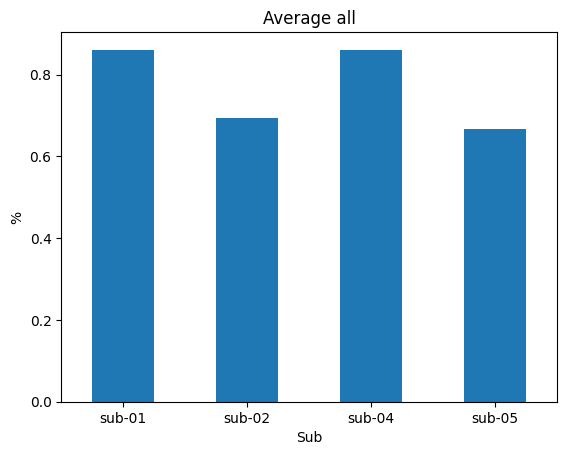

In [88]:
ax = df.T.plot.bar(y=0, rot=0, legend=False)

# Add labels and title for clarity
plt.xlabel("Sub")
plt.ylabel("%")
plt.title("Average all")

# Display the plot
plt.show()

In [73]:
#df.to_csv('bixby_data/overall_average.csv')

In [89]:
curr_type = 'task_split'
curr_dict = {}
for sub in all_sub_output_dict.keys():
    curr_dict[sub] = all_sub_output_dict[sub][curr_type]
df = pd.DataFrame(curr_dict)

In [78]:
df.to_csv('bixby_data/by_task_average.csv')

In [75]:
curr_type = 'run_split'
curr_dict = {}
for sub in all_sub_output_dict.keys():
    curr_dict[sub] = all_sub_output_dict[sub][curr_type]
df = pd.DataFrame(curr_dict)

In [76]:
df.to_csv('bixby_data/by_run_average.csv')

In [79]:
curr_type = 'run_task_split'
curr_dict = {}
for sub in all_sub_output_dict.keys():
    curr_dict[sub] = all_sub_output_dict[sub][curr_type]
data_list = [{'sub': k, **v} for k, v in curr_dict.items()]
df = pd.json_normalize(data_list).set_index('sub').T

In [80]:
df.to_csv('bixby_data/by_run+task_average.csv')